# Họ và Tên Lê Phước Lộc
# MSSV 197CT09831

### Câu 1 (2 điểm): Cho một ảnh bất kỳ (tên ảnh do sinh viên tự đặt, ví dụ: `my_image.jpg`) và thực hiện các yêu cầu sau:

* Viết chương trình sử dụng Bilateral filter để làm mịn ảnh. (0.5 điểm)  
* Viết chương trình sử dụng Canny Edge Detection để xác định biên của hình ảnh. (0.5 điểm)  
* Đổi màu ảnh bằng cách hoán đổi kênh màu theo thứ tự (ví dụ: BGR → BRG) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)  
* Chuyển ảnh sang không gian màu YCrCb và tách riêng 3 kênh Y, Cr, Cb, lưu thành ảnh grayscale tương ứng (`[ten_anh]_Y.jpg`, `[ten_anh]_Cr.jpg`, `[ten_anh]_Cb.jpg`). (0.5 điểm)


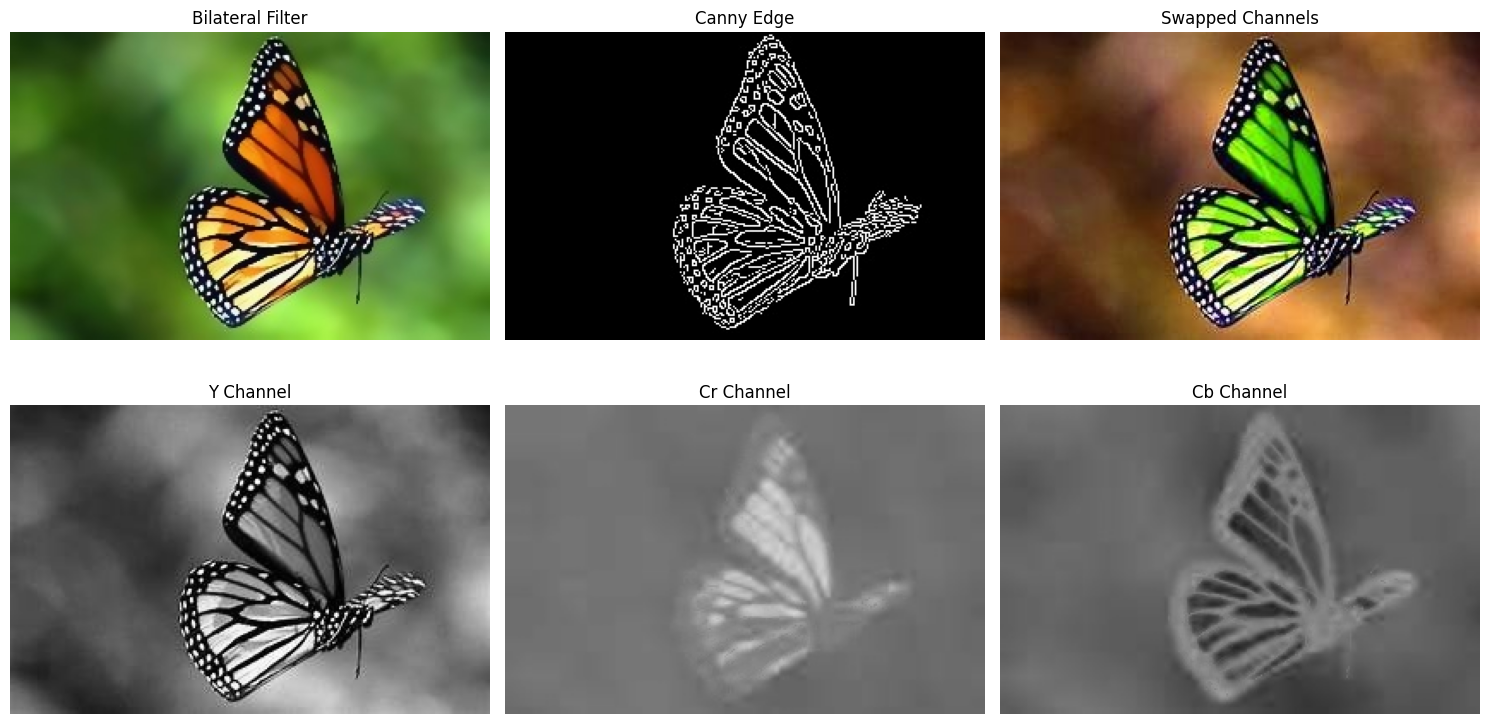

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Đặt tên ảnh của bạn ở đây
image_name = 'image1.jpg'  # Thay bằng tên ảnh của bạn

# Đọc ảnh
img = cv2.imread(image_name)

# 1. Bilateral filter làm mịn ảnh
bilateral = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
cv2.imwrite(f"{image_name.split('.')[0]}_bilateral.jpg", bilateral)

# 2. Canny Edge Detection xác định biên
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)
cv2.imwrite(f"{image_name.split('.')[0]}_canny.jpg", edges)

# 3. Đổi màu ảnh bằng cách hoán đổi kênh màu (BGR -> BRG)
swapped = img[:, :, [0, 2, 1]]  # BGR -> BRG
cv2.imwrite(f"{image_name.split('.')[0]}_swapped.jpg", swapped)

# 4. Chuyển sang YCrCb và tách kênh
ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)
cv2.imwrite(f"{image_name.split('.')[0]}_Y.jpg", Y)
cv2.imwrite(f"{image_name.split('.')[0]}_Cr.jpg", Cr)
cv2.imwrite(f"{image_name.split('.')[0]}_Cb.jpg", Cb)

# Hiển thị các ảnh kết quả ngay trong notebook
result_files = [
    f"{image_name.split('.')[0]}_bilateral.jpg",
    f"{image_name.split('.')[0]}_canny.jpg",
    f"{image_name.split('.')[0]}_swapped.jpg",
    f"{image_name.split('.')[0]}_Y.jpg",
    f"{image_name.split('.')[0]}_Cr.jpg",
    f"{image_name.split('.')[0]}_Cb.jpg"
]

titles = [
    "Bilateral Filter",
    "Canny Edge",
    "Swapped Channels",
    "Y Channel",
    "Cr Channel",
    "Cb Channel"
]

plt.figure(figsize=(15, 8))
for i, (file, title) in enumerate(zip(result_files, titles)):
    img = cv2.imread(file)
    if len(img.shape) == 2:  # grayscale
        img_show = img
        cmap = 'gray'
    else:
        img_show = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        cmap = None
    plt.subplot(2, 3, i+1)
    plt.imshow(img_show, cmap=cmap)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật biến đổi hình học và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.

### Yêu cầu:

1. Menu gồm:  
* Phóng to ảnh (Zoom bằng resize) (0.5 điểm)  
* Xoay ảnh (góc ngẫu nhiên từ 0–360 độ) (0.5 điểm)  
* Lật ảnh ngang (0.5 điểm)  
* Lật ảnh dọc (0.5 điểm)  
* Cắt ảnh (crop ngẫu nhiên vùng giữa ảnh) (0.5 điểm)  
* Thêm viền (padding màu ngẫu nhiên) (0.5 điểm)

2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)

3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
* Z: Zoom  
* T: Rotate  
* H: Horizontal Flip  
* V: Vertical Flip  
* C: Crop  
* P: Padding (0.5 điểm)

4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
   Ví dụ: `result_crop_cat.jpg`, `result_rotate_image1.jpg` (0.5 điểm)


In [4]:
import cv2
import numpy as np
import os
import random
from matplotlib import pyplot as plt
from ipywidgets import interact, Dropdown

# --- Cấu hình thư mục lưu và danh sách ảnh ---
OUTPUT_DIR = "output_2"
IMAGE_PATHS = ["image1.jpg", "image2.jpg", "image3.jpg"]

# --- Đảm bảo thư mục lưu kết quả tồn tại ---
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load ảnh ---
def load_images(paths):
    images = {}
    for path in paths:
        img = cv2.imread(path)
        if img is not None:
            images[path] = img
        else:
            print(f"[!] Không thể đọc ảnh: {path}")
    return images

# --- Hiển thị ảnh kết quả ---
def show_results(imgs, titles):
    for img, title in zip(imgs, titles):
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title(title)
        plt.axis('off')
        plt.show()

# --- Các hàm xử lý ---
def zoom(img):
    scale = random.uniform(1.2, 2.0)
    zoomed = cv2.resize(img, None, fx=scale, fy=scale)
    return zoomed, "zoom", f"Phóng ảnh tỉ lệ {round(scale, 2)}"

def rotate(img):
    angle = random.randint(0, 360)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1)
    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated, "rotate", f"Xoay {angle} độ"

def hflip(img):
    return cv2.flip(img, 1), "hflip", "Lật ngang"

def vflip(img):
    return cv2.flip(img, 0), "vflip", "Lật dọc"

def crop(img, ratio=0.5):
    h, w = img.shape[:2]
    ch, cw = int(h * ratio), int(w * ratio)
    start_y = (h - ch) // 2
    start_x = (w - cw) // 2
    cropped = img[start_y:start_y + ch, start_x:start_x + cw]
    return cropped, "crop", f"Cắt trung tâm {ratio}"

def padding(img, pad=30):
    color = [random.randint(0, 255) for _ in range(3)]
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=color)
    return padded, "padding", f"Thêm viền màu {color}"

# --- Ánh xạ phương thức xử lý ---
TRANSFORM_FUNCS = {
    "Zoom": zoom,
    "Rotate": rotate,
    "Horizontal Flip": hflip,
    "Vertical Flip": vflip,
    "Crop": crop,
    "Padding": padding,
}

# --- Áp dụng xử lý ---
def apply_transformation(method_name):
    if not ORIGINAL_IMAGES:
        print("Không có ảnh nào để xử lý.")
        return

    print(f"\n[~] Đang xử lý với phương pháp: {method_name}")
    transform = TRANSFORM_FUNCS.get(method_name)
    if transform is None:
        print("Phương pháp không hợp lệ.")
        return

    results, titles = [], []
    for path, img in ORIGINAL_IMAGES.items():
        base = os.path.splitext(os.path.basename(path))[0]
        result_img, suffix, msg = transform(img.copy())

        filename = f"result_{suffix}_{base}.jpg"
        output_path = os.path.join(OUTPUT_DIR, filename)
        cv2.imwrite(output_path, result_img)

        print(f"  -> {base}: {msg}. Lưu tại {output_path}")
        results.append(result_img)
        titles.append(filename)

    show_results(results, titles)

# --- Khởi tạo ---
ORIGINAL_IMAGES = load_images(IMAGE_PATHS)

# --- Menu chọn ---
dropdown = Dropdown(
    options=list(TRANSFORM_FUNCS.keys()),
    description="Chọn xử lý:",
    style={'description_width': 'initial'}
)

# --- Chạy tương tác ---
interact(apply_transformation, method_name=dropdown)


interactive(children=(Dropdown(description='Chọn xử lý:', options=('Zoom', 'Rotate', 'Horizontal Flip', 'Verti…

<function __main__.apply_transformation(method_name)>

### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

* Thêm viền đen 20 pixel cho ảnh đầu tiên. (0.5 điểm)  
* Xoay ảnh thứ hai 45 độ và phóng to 1.5 lần. (0.5 điểm)  
* Tăng kích thước ảnh thứ ba lên 4 lần, sau đó áp dụng Bilateral Filter với tham số tùy chọn. (1.5 điểm)  
* Thay đổi độ sáng và độ tương phản ảnh thứ ba theo công thức:

$$
I_{out}(x, y) = \alpha \cdot I_{in}(x, y) + \beta
$$

Trong đó:  

$$
\alpha \in [0.6, 2.0], \quad \beta \in [-60, 60]
$$

Giá trị đầu ra cần được giới hạn trong khoảng [0, 255] bằng công thức:

$$
I_{out}(x, y) = \text{clip}(I_{out}(x, y), 0, 255)
$$


# Chúc các bạn thi may mắn và đạt điểm 10.

✅ Ảnh 1 đã thêm viền đen: output_3/result_padding_image1.jpg


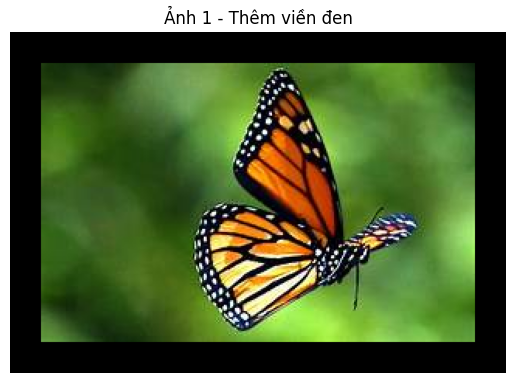

✅ Ảnh 2 đã xoay 45 độ và phóng 1.5 lần: output_3/result_rotate_scale_image2.jpg


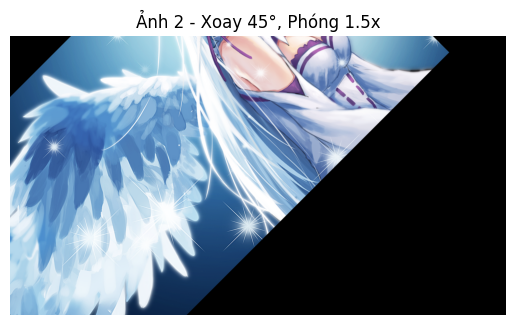

✅ Ảnh 3 đã xử lý (Zoom 4x + Bilateral + α=1.0, β=-2): output_3/result_final_image3.jpg


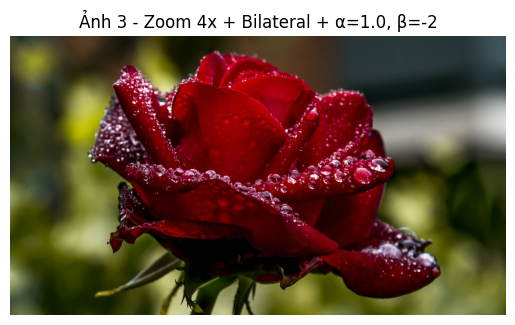

In [6]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Tạo thư mục lưu ảnh ---
os.makedirs("output_3", exist_ok=True)

# --- Hàm hiển thị ảnh ---
def show_image(img, title="Image"):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

# --- Load ảnh ---
IMAGE_PATHS = ["image1.jpg", "image2.jpg", "image3.jpg"]
IMAGES = []

for path in IMAGE_PATHS:
    img = cv2.imread(path)
    if img is None:
        print(f"[!] Không đọc được ảnh: {path}")
    else:
        IMAGES.append((path, img))

# --- Ảnh 1: Thêm viền đen 20px ---
if len(IMAGES) >= 1:
    path, img = IMAGES[0]
    padded = cv2.copyMakeBorder(img, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=(0, 0, 0))
    out_name = "output_3/result_padding_" + os.path.basename(path)
    cv2.imwrite(out_name, padded)
    print(f"✅ Ảnh 1 đã thêm viền đen: {out_name}")
    show_image(padded, "Ảnh 1 - Thêm viền đen")

# --- Ảnh 2: Xoay 45 độ + phóng 1.5 lần ---
if len(IMAGES) >= 2:
    path, img = IMAGES[1]
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, 45, 1.5)
    rotated = cv2.warpAffine(img, M, (int(w * 1.5), int(h * 1.5)))
    out_name = "output_3/result_rotate_scale_" + os.path.basename(path)
    cv2.imwrite(out_name, rotated)
    print(f"✅ Ảnh 2 đã xoay 45 độ và phóng 1.5 lần: {out_name}")
    show_image(rotated, "Ảnh 2 - Xoay 45°, Phóng 1.5x")

# --- Ảnh 3: Phóng to 4x + Bilateral Filter + chỉnh sáng/contrast ---
if len(IMAGES) >= 3:
    path, img = IMAGES[2]

    # Phóng to 4 lần
    enlarged = cv2.resize(img, None, fx=4.0, fy=4.0, interpolation=cv2.INTER_LINEAR)

    # Áp dụng Bilateral Filter
    filtered = cv2.bilateralFilter(enlarged, d=9, sigmaColor=75, sigmaSpace=75)

    # Điều chỉnh sáng và tương phản
    alpha = np.random.uniform(0.6, 2.0)       # hệ số tương phản
    beta = np.random.randint(-60, 61)         # độ sáng

    adjusted = cv2.convertScaleAbs(filtered, alpha=alpha, beta=beta)

    out_name = "output_3/result_final_" + os.path.basename(path)
    cv2.imwrite(out_name, adjusted)
    print(f"✅ Ảnh 3 đã xử lý (Zoom 4x + Bilateral + α={round(alpha,2)}, β={beta}): {out_name}")
    show_image(adjusted, f"Ảnh 3 - Zoom 4x + Bilateral + α={round(alpha,2)}, β={beta}")
